Accuracy: 0.8701298701298701
              precision    recall  f1-score   support

           0       0.83      0.95      0.89        41
           1       0.93      0.78      0.85        36

    accuracy                           0.87        77
   macro avg       0.88      0.86      0.87        77
weighted avg       0.88      0.87      0.87        77



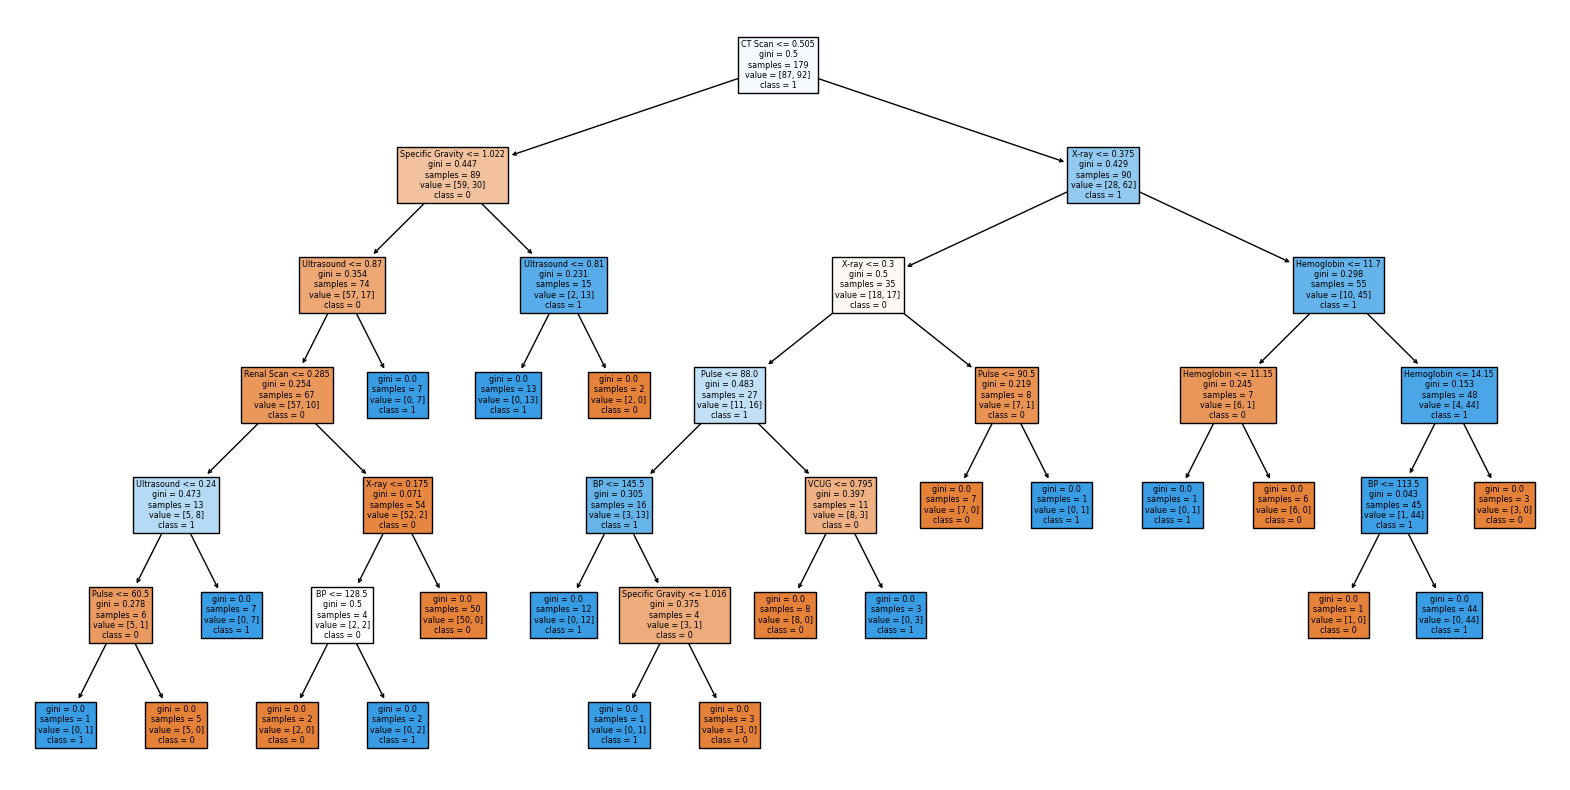

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn import tree
import matplotlib.pyplot as plt
import pandas as pd
# Load the data
data = pd.read_csv('/content/Book4.csv')

# Split the data into features (X) and target (y)
X = data.drop(columns=['Patient ID', 'y'])  # Dropping 'Patient ID' and 'y' as 'y' is the target
y = data['y']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create the decision tree classifier
clf = DecisionTreeClassifier(random_state=42)

# Train the model
clf.fit(X_train, y_train)

# Predict on the test set
y_pred = clf.predict(X_test)

# Evaluate the model
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(classification_report(y_test, y_pred))

# Plot the decision tree
plt.figure(figsize=(20,10))
tree.plot_tree(clf, feature_names=X.columns, class_names=['0', '1'], filled=True)
plt.show()


In [7]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Load the dataset (replace 'your_dataset.csv' with the actual dataset file)
data = pd.read_csv('/content/Book4.csv')

# Display the first few rows of the dataset
print(data.head())

# Select important features and the target variable
features = ['CT Scan','Specific Gravity', 'X-ray','Ultrasound','Renal Scan','Cystoscopy','BP']
X = data[features]
y = data['y']

# Handle any missing values (if necessary)
X.fillna(X.mean(), inplace=True)

# Encode categorical variables if they exist (this might not be necessary depending on your data)
# If any of the features are categorical, use LabelEncoder or pd.get_dummies
# Example: X['Sex'] = LabelEncoder().fit_transform(X['Sex'])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Gradient Boosting Classifier
model = GradientBoostingClassifier()

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)

print(f'Accuracy: {accuracy:.2f}')
print(f'ROC AUC Score: {roc_auc:.2f}')
print('Classification Report:')
print(classification_report(y_test, y_pred))

# Save the trained model if necessary
# import joblib
# joblib.dump(model, 'kidney_disease_prediction_model.pkl')

   Patient ID  Age  Sex   BP  Pulse  Specific Gravity  Hemoglobin  Ultrasound  \
0           1   58    1  124     98             1.022        13.3        0.82   
1           2   71    0  152     77             1.014        11.5        0.74   
2           3   48    1  138     99             1.011        14.2        0.68   
3           4   34    0  145     60             1.012        14.3        0.24   
4           5   62    1  122     70             1.013        13.5        0.40   

   CT Scan  X-ray  Cystoscopy  VCUG  Renal Scan  y  
0     0.81   0.50        0.75  0.71        0.09  1  
1     0.90   0.33        0.71  0.53        0.77  0  
2     0.62   0.93        0.78  0.53        0.07  0  
3     0.98   0.01        0.14  0.48        0.84  1  
4     0.61   0.23        0.20  0.50        0.44  1  
Accuracy: 0.92
ROC AUC Score: 0.96
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.91      0.91        23
           1       0.93     

<ipython-input-7-7abfb07754a0>:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.fillna(X.mean(), inplace=True)


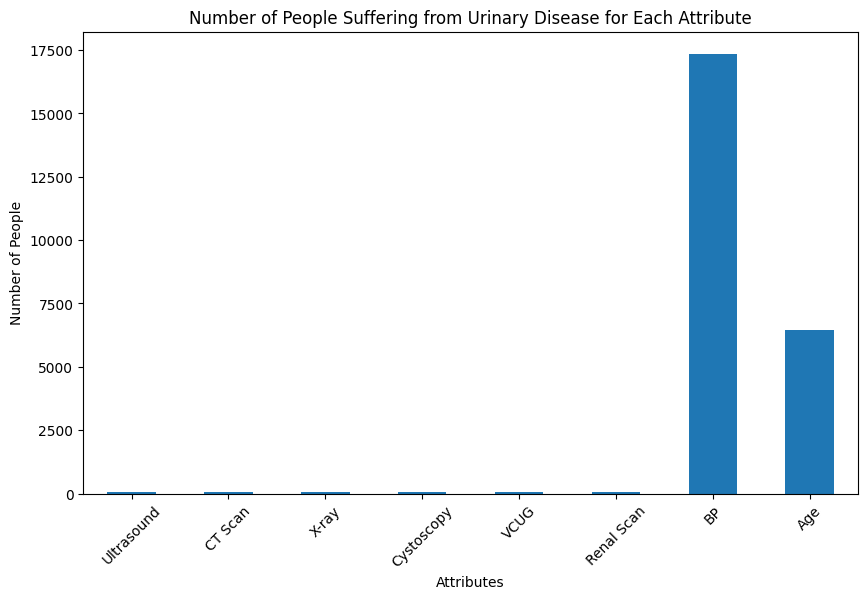

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('/content/Book4.csv')

# Define the priority order of x attributes
x_attributes = ['Ultrasound', 'CT Scan', 'X-ray', 'Cystoscopy', 'VCUG', 'Renal Scan','BP','Age']

# Filter the dataset for people suffering from kidney diseases (y == 1)
kidney_disease_df = df[df['y'] == 1]

# Calculate the number of people suffering from urinary disease for each x attribute
urinary_disease_counts = kidney_disease_df[x_attributes].sum()

# Plot the graph
plt.figure(figsize=(10, 6))
urinary_disease_counts.plot(kind='bar')
plt.xlabel('Attributes')
plt.ylabel('Number of People')
plt.title('Number of People Suffering from Urinary Disease for Each Attribute')
plt.xticks(rotation=45)
plt.show()

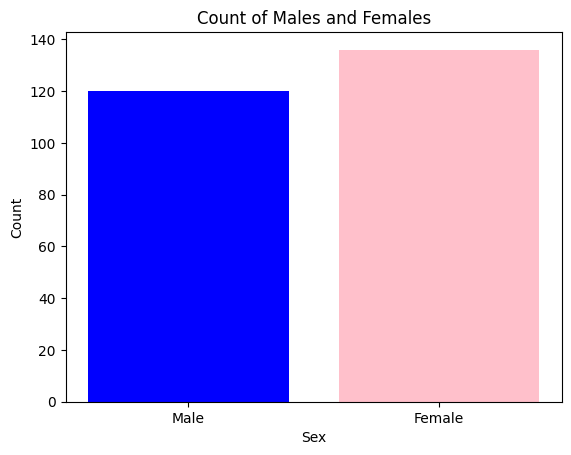

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data from a CSV file
df = pd.read_csv('Book4.csv')

# Ensure the 'Sex' column is properly labeled (assuming 0 for male and 1 for female)
if 'Sex' in df.columns:
    # Count the number of occurrences of each sex
    sex_counts = df['Sex'].value_counts()

    # Create a bar chart instead of a histogram since we are dealing with counts
    plt.bar(['Male', 'Female'], sex_counts.sort_index(), color=['blue', 'pink'])
    plt.xlabel('Sex')
    plt.ylabel('Count')
    plt.title('Count of Males and Females')
    plt.show()
else:
    print("The 'Sex' column is not found in the dataset.")


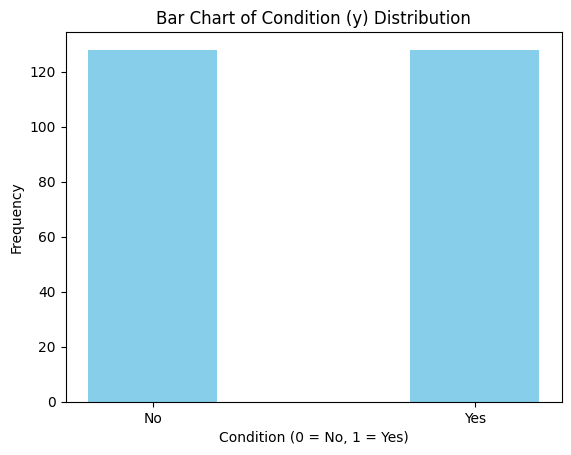

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data from a CSV file
df = pd.read_csv('Book4.csv')

# Ensure the 'y' column is present in the dataset
if 'y' in df.columns:
    # Count the number of occurrences of each value in 'y'
    y_counts = df['y'].value_counts().sort_index()

    # Create a bar chart for the 'y' attribute with space between the bars
    plt.bar(y_counts.index, y_counts.values, color='skyblue', width=0.4)  # width controls the bar width
    plt.xlabel('Condition (0 = No, 1 = Yes)')
    plt.ylabel('Frequency')
    plt.title('Bar Chart of Condition (y) Distribution')
    plt.xticks([0, 1], ['No', 'Yes'])  # Label the x-axis with 'No' and 'Yes'
    plt.show()
else:
    print("The 'y' column is not found in the dataset.")


# different types of models testing

In [1]:
# logistic regression
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Load data from a CSV file (replace 'your_data.csv' with your actual file path)
df = pd.read_csv('/content/Book4.csv')

# Inspect the data
print(df.head())  # Check the first few rows to confirm it's loaded properly

# Split the dataset into features (X) and target (y)
X = df[['CT Scan', 'Specific Gravity', 'X-ray', 'Ultrasound', 'Renal Scan', 'Cystoscopy', 'BP']]
y = df['y']  # Target attribute

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Logistic Regression model
model = LogisticRegression()

# Train the model
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

# Print results
print(f"Accuracy: {accuracy * 100:.2f}%")
print("Confusion Matrix:")
print(conf_matrix)


   Patient ID  Age  Sex   BP  Pulse  Specific Gravity  Hemoglobin  Ultrasound  \
0           1   58    1  124     98             1.022        13.3        0.82   
1           2   71    0  152     77             1.014        11.5        0.74   
2           3   48    1  138     99             1.011        14.2        0.68   
3           4   34    0  145     60             1.012        14.3        0.24   
4           5   62    1  122     70             1.013        13.5        0.40   

   CT Scan  X-ray  Cystoscopy  VCUG  Renal Scan  y  
0     0.81   0.50        0.75  0.71        0.09  1  
1     0.90   0.33        0.71  0.53        0.77  0  
2     0.62   0.93        0.78  0.53        0.07  0  
3     0.98   0.01        0.14  0.48        0.84  1  
4     0.61   0.23        0.20  0.50        0.44  1  
Accuracy: 80.77%
Confusion Matrix:
[[18  5]
 [ 5 24]]


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [3]:
# svm (support vector machine)
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

# Load data from a CSV file (replace 'your_data.csv' with your actual file path)
df = pd.read_csv('/content/Book4.csv')

# Inspect the data (optional)
print(df.head())  # Check the first few rows to ensure the data is loaded properly

# Split the dataset into features (X) and target (y)
X = df[['CT Scan', 'Specific Gravity', 'X-ray', 'Ultrasound', 'Renal Scan', 'Cystoscopy', 'BP']]
y = df['y']  # Target attribute

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the SVM model
model = SVC(kernel='linear')  # You can try other kernels like 'rbf', 'poly', etc.

# Train the model
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

# Print results
print(f"Accuracy: {accuracy * 100:.2f}%")
print("Confusion Matrix:")
print(conf_matrix)


   Patient ID  Age  Sex   BP  Pulse  Specific Gravity  Hemoglobin  Ultrasound  \
0           1   58    1  124     98             1.022        13.3        0.82   
1           2   71    0  152     77             1.014        11.5        0.74   
2           3   48    1  138     99             1.011        14.2        0.68   
3           4   34    0  145     60             1.012        14.3        0.24   
4           5   62    1  122     70             1.013        13.5        0.40   

   CT Scan  X-ray  Cystoscopy  VCUG  Renal Scan  y  
0     0.81   0.50        0.75  0.71        0.09  1  
1     0.90   0.33        0.71  0.53        0.77  0  
2     0.62   0.93        0.78  0.53        0.07  0  
3     0.98   0.01        0.14  0.48        0.84  1  
4     0.61   0.23        0.20  0.50        0.44  1  
Accuracy: 78.85%
Confusion Matrix:
[[18  5]
 [ 6 23]]


In [5]:
# knn
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Load data from a CSV file (replace 'your_data.csv' with your actual file path)
df = pd.read_csv('/content/Book4.csv')

# Inspect the data (optional)
print(df.head())  # Check the first few rows to ensure the data is loaded properly

# Split the dataset into features (X) and target (y)
X = df[['CT Scan', 'Specific Gravity', 'X-ray', 'Ultrasound', 'Renal Scan', 'Cystoscopy', 'BP']]
y = df['y']  # Target attribute

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the KNN model (you can adjust n_neighbors for different K values)
knn = KNeighborsClassifier(n_neighbors=5)  # Set the number of neighbors (K)

# Train the model
knn.fit(X_train, y_train)

# Make predictions on the test set
y_pred = knn.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

# Print results
print(f"Accuracy: {accuracy * 100:.2f}%")
print("Confusion Matrix:")
print(conf_matrix)


   Patient ID  Age  Sex   BP  Pulse  Specific Gravity  Hemoglobin  Ultrasound  \
0           1   58    1  124     98             1.022        13.3        0.82   
1           2   71    0  152     77             1.014        11.5        0.74   
2           3   48    1  138     99             1.011        14.2        0.68   
3           4   34    0  145     60             1.012        14.3        0.24   
4           5   62    1  122     70             1.013        13.5        0.40   

   CT Scan  X-ray  Cystoscopy  VCUG  Renal Scan  y  
0     0.81   0.50        0.75  0.71        0.09  1  
1     0.90   0.33        0.71  0.53        0.77  0  
2     0.62   0.93        0.78  0.53        0.07  0  
3     0.98   0.01        0.14  0.48        0.84  1  
4     0.61   0.23        0.20  0.50        0.44  1  
Accuracy: 76.92%
Confusion Matrix:
[[17  6]
 [ 6 23]]


In [6]:
# Gradient Descent for logistic regression
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Gradient descent function for logistic regression
def gradient_descent(X, y, learning_rate, iterations):
    m = X.shape[0]  # Number of training examples
    n = X.shape[1]  # Number of features
    theta = np.zeros((n, 1))  # Initialize weights
    y = y.reshape(m, 1)  # Reshape y to be a column vector

    for i in range(iterations):
        z = np.dot(X, theta)
        h = sigmoid(z)
        gradient = np.dot(X.T, (h - y)) / m
        theta -= learning_rate * gradient

    return theta

# Prediction function
def predict(X, theta):
    z = np.dot(X, theta)
    return sigmoid(z) >= 0.5  # Classify as 1 if sigmoid(z) >= 0.5, else 0

# Load data from a CSV file (replace 'your_data.csv' with your actual file path)
df = pd.read_csv('/content/Book4.csv')

# Inspect the data (optional)
print(df.head())

# Prepare the dataset (features and target)
X = df[['CT Scan', 'Specific Gravity', 'X-ray', 'Ultrasound', 'Renal Scan', 'Cystoscopy', 'BP']].values
y = df['y'].values

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize features (gradient descent performs better with normalized data)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Add a bias term (column of 1's) to X (for the intercept in logistic regression)
X_train = np.hstack((np.ones((X_train.shape[0], 1)), X_train))
X_test = np.hstack((np.ones((X_test.shape[0], 1)), X_test))

# Set hyperparameters for gradient descent
learning_rate = 0.01
iterations = 1000

# Train the model using gradient descent
theta = gradient_descent(X_train, y_train, learning_rate, iterations)

# Make predictions on the test set
y_pred = predict(X_test, theta)

# Evaluate the model
accuracy = np.mean(y_pred == y_test) * 100

# Print results
print(f"Accuracy: {accuracy:.2f}%")


   Patient ID  Age  Sex   BP  Pulse  Specific Gravity  Hemoglobin  Ultrasound  \
0           1   58    1  124     98             1.022        13.3        0.82   
1           2   71    0  152     77             1.014        11.5        0.74   
2           3   48    1  138     99             1.011        14.2        0.68   
3           4   34    0  145     60             1.012        14.3        0.24   
4           5   62    1  122     70             1.013        13.5        0.40   

   CT Scan  X-ray  Cystoscopy  VCUG  Renal Scan  y  
0     0.81   0.50        0.75  0.71        0.09  1  
1     0.90   0.33        0.71  0.53        0.77  0  
2     0.62   0.93        0.78  0.53        0.07  0  
3     0.98   0.01        0.14  0.48        0.84  1  
4     0.61   0.23        0.20  0.50        0.44  1  
Accuracy: 50.89%


In [8]:
# GradientBoostingClassifier
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Load data from a CSV file (replace 'your_data.csv' with your actual file path)
df = pd.read_csv('/content/Book4.csv')

# Inspect the data (optional)
print(df.head())  # Check the first few rows to ensure the data is loaded properly

# Prepare the dataset (features and target)
X = df[['CT Scan', 'Specific Gravity', 'X-ray', 'Ultrasound', 'Renal Scan', 'Cystoscopy', 'BP']]
y = df['y']  # Target attribute

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Gradient Boosting Classifier
gbc = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

# Train the model
gbc.fit(X_train, y_train)

# Make predictions on the test set
y_pred = gbc.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

# Print results
print(f"Accuracy: {accuracy * 100:.2f}%")
print("Confusion Matrix:")
print(conf_matrix)


   Patient ID  Age  Sex   BP  Pulse  Specific Gravity  Hemoglobin  Ultrasound  \
0           1   58    1  124     98             1.022        13.3        0.82   
1           2   71    0  152     77             1.014        11.5        0.74   
2           3   48    1  138     99             1.011        14.2        0.68   
3           4   34    0  145     60             1.012        14.3        0.24   
4           5   62    1  122     70             1.013        13.5        0.40   

   CT Scan  X-ray  Cystoscopy  VCUG  Renal Scan  y  
0     0.81   0.50        0.75  0.71        0.09  1  
1     0.90   0.33        0.71  0.53        0.77  0  
2     0.62   0.93        0.78  0.53        0.07  0  
3     0.98   0.01        0.14  0.48        0.84  1  
4     0.61   0.23        0.20  0.50        0.44  1  
Accuracy: 92.31%
Confusion Matrix:
[[21  2]
 [ 2 27]]
